In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd # Zarządzenie ramkami danych (DataFrame)
import statsmodels.api as sm # zaawansowane modelowanie statystyczne (np. regresja OLS)

In [9]:
# --- Wczytywanie i czyszczenie danych z pliku CSV, zmieszczającym informację o położeniach granicy obcięcia ---

data = "E_cutoff.csv"

# Wczytanie pliku z uwzględnieniem specyficznego kodowania znaków (standard Excela w systemie Windows)
df = pd.read_csv(data, encoding="windows-1250")

# Usunięcie pierwszego wiersza (bo zawiera jednostki wielkości fizycznych)
df = df[1:]

# Usunięcie niepotrzebnej kolumny ze stosunkiem energii jonizacji do energii oscylacji (I_p/U_p)
df = df.drop(columns=["I_p/U_p"])

# Konwersja tekstowych znaczników braku danych "--" na standardowe obiekty np.nan (Not a Number)
df = df.replace("--", np.nan)

# Jawne rzutowanie kolumn numerycznych na typ zmiennoprzecinkowy (float) 
# Zapobiega to błędom obliczeniowym w statsmodels wynikającym z traktowania liczb jako obiektów typu string
columns_to_float = [
    "E_start", "omega_0", "E_0", "U_p", "E_cutoff_d", 
    "E_cutoff_Eh", "I_p", "E_classic", "N_classic"
]
df[columns_to_float] = df[columns_to_float].astype("float")

# Wyświetlenie oczyszczonej ramki danych
df

,N_cutoff_d,N_cutoff_Eh,E_start,n,omega_0,E_0,U_p,E_cutoff_d,E_cutoff_Eh,I_p,E_classic,N_classic
1,NaN,49.0,0.500000,10.0,0.06,0.100,0.694444,NaN,2.94,0.5,2.861389,47.689814
2,17.0,17.0,0.500000,10.0,0.06,0.040,0.111111,1.02,1.02,0.5,1.012222,16.870370
3,21.0,21.0,0.500000,10.0,0.06,0.050,0.173611,1.26,1.26,0.5,1.210347,20.172453
4,21.0,21.0,0.500000,10.0,0.06,0.060,0.250000,1.26,1.26,0.5,1.452500,24.208333
5,NaN,41.0,0.500000,10.0,0.06,0.090,0.562500,NaN,2.46,0.5,2.443125,40.718750
...,...,...,...,...,...,...,...,...,...,...,...,...
105,NaN,NaN,0.015864,10.0,0.06,0.035,0.085069,NaN,NaN,0.5,0.929670,15.494502
106,NaN,NaN,0.015864,10.0,0.06,0.025,0.043403,NaN,NaN,0.5,0.797587,13.293113
107,55.0,41.0,0.500000,10.0,0.06,0.090,0.562500,3.30,2.46,0.5,2.443125,40.718750
108,NaN,NaN,0.500000,10.0,0.06,0.100,0.694444,NaN,NaN,0.5,2.861389,47.689814


In [4]:
# --- Podział zbioru danych na podstawie metody wyznaczania energii cutoffu ---
# Ze względu na potencjalne braki danych (NaN), tworzone są dwie niezależne ramki danych.
# Zapobiega to zaburzeniu wyników regresji dla jednej metody przez brakujące pomiary w drugiej.

# 1. Zbiór danych dla metody dipolowej (_d)
# Usunięcie wierszy, w których nie wyznaczono energii odcięcia z dipola, oraz odrzucenie zmiennych związanych z metodą Ehrenfesta
df_d = df.dropna(subset=["E_cutoff_d"])
df_d = df_d.drop(columns=["N_cutoff_Eh", "E_cutoff_Eh"])

# 2. Zbiór danych dla metody twierdzenia Ehrenfesta (_Eh)
# Usunięcie wierszy z brakami dla metody Ehrenfesta oraz odrzucenie zmiennych związanych z metodą dipolową
df_Eh = df.dropna(subset=["E_cutoff_Eh"])
df_Eh = df_Eh.drop(columns=["N_cutoff_d", "E_cutoff_d"])

In [5]:
# --- Regresja liniowa OLS dla metody dipolowej ---
# Celem jest dopasowanie parametrów klasycznego wzoru na odcięcie widma: E_cutoff = alpha * U_p + beta, gdzie beta = C_I_p * I_p.
# Wyznaczone wartości parametrów (wraz z niepewnościami) pozwalają zweryfikować teorię trzech kroków (gdzie teoretycznie alpha = 3.17, beta = 1.32*I_p).

# 1. Obliczenie rzeczywistej energii odcięcia Y_d (rząd harmonicznej pomnożony przez częstość lasera podstawowego)
df_d["Y_d"] = df_d["N_cutoff_d"] * df_d["omega_0"]

# 2. Przygotowanie zmiennych X oraz y do pakietu statsmodels.
# Metoda sm.add_constant dodaje kolumnę z jedynkami, co umożliwia wyznaczenie wyrazu wolnego (beta).
X_d = df_d["U_p"]
X_d_with_constant = sm.add_constant(X_d)
y_d = df_d["Y_d"]

# 3. Dopasowanie modelu regresji metodą najmniejszych kwadratów (Ordinary Least Squares)
model_d = sm.OLS(y_d, X_d_with_constant).fit()

# 4. Ekstrakcja współczynników kierunkowych, błędów standardowych (1-sigma) oraz współczynnika determinacji R^2
coefficients_d = model_d.params
std_errors_d = model_d.bse
r_squared_d = model_d.rsquared

# Przypisanie wyników dla nachylenia prostej (alpha) oraz wyrazu wolnego (beta)
alpha_d = coefficients_d['U_p']
dalpha_d = std_errors_d['U_p']
beta_d = coefficients_d['const']
dbeta_d = std_errors_d['const']

# Wyznaczenie współczynnika przy energii jonizacji (C_I_p), przy założeniu stałej wartości I_p dla danej serii danych
C_I_p_d = beta_d / df_d["I_p"].iloc[0]
dC_I_p_d = dbeta_d / df_d["I_p"].iloc[0]

# --- Prezentacja wyników ---
# Wyświetlenie dopasowanych parametrów wraz z przedziałem ufności 2-sigma (około 95% przedziału ufności)
print("--- WYNIKI DOPASOWANIA (2-sigma) ---")
print(f"Alpha   : {alpha_d:.4f} ± {2 * dalpha_d:.4f}")
print(f"Beta    : {beta_d:.4f} ± {2 * dbeta_d:.4f}")
print(f"C_I_p_d : {C_I_p_d:.4f} ± {2 * dC_I_p_d:.4f}")
print(f"R^2     : {r_squared_d:.5f}")

--- WYNIKI DOPASOWANIA (2-sigma) ---
Alpha   : 4.0758 ± 0.4441
Beta    : 0.3501 ± 0.1176
C_I_p_d : 0.7001 ± 0.2352
R^2     : 0.85314


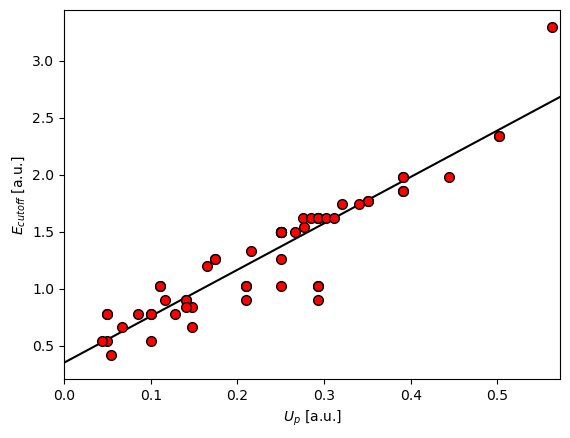

In [222]:
# --- Wykres regresji liniowej energii odcięcia dla metody dipolowej ---
# Wykres przedstawia wyznaczoną energię odcięcia (E_cutoff) w funkcji energii ponderomotorycznej (U_p).
# Punkty danych są zestawione z linią trendu OLS.

# Przygotowanie siatki argumentów dla prostej regresyjnej
x_d_temp = np.linspace(0, np.max(X_d) + 0.01, 100)

plt.figure(figsize=(8, 5))

# Rysowanie punktów pomiarowych
plt.errorbar(
    X_d,
    y_d,
    fmt="o",        # Kształt punktu (okrąg)
    color="red",
    ms=7,           # Wielkość punktu
    mec="k",        # Kolor krawędzi punktu (czarny)
    zorder=5,       # Rysowanie punktów nad linią regresji
    label="Dane z symulacji TDSE",
)

# Rysowanie dopasowanej prostej regresyjnej: y = alpha * U_p + beta
plt.plot(
    x_d_temp, 
    alpha_d * x_d_temp + beta_d, 
    color='k', 
    linestyle='-', 
    lw=1.5, 
    label=f"Dopasowanie OLS ($\alpha$ = {alpha_d:.2f})"
)

# Konfiguracja osi i estetyki wykresu
plt.xlim(0, X_d.max() + 0.01)
plt.xlabel(r"$U_p$ [a.u.]")
plt.ylabel(r"$E_{cutoff}$ [a.u.]")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

In [223]:
# --- Analiza rezyduów i propagacja niepewności dla metody dipolowej ---

# Obliczenie wartości teoretycznych (przewidywanych przez model OLS) dla punktów pomiarowych
y_pred_X_d = alpha_d * X_d + beta_d

# Obliczenie niepewności standardowej (1-sigma) dla wartości przewidywanych.
dy_1s_d = np.sqrt((X_d**2) * (dalpha_d**2) + (dbeta_d**2))

# Przeliczenie na niepewność 2-sigma, odpowiadającą przedziałowi ufności ok. 95%
yerr_residua_d = 2 * dy_1s_d

# 4. Obliczenie rezyduów (odchyleń wartości uzyskanych z TDSE od prostej regresyjnej)
residua_d = y_d - y_pred_X_d

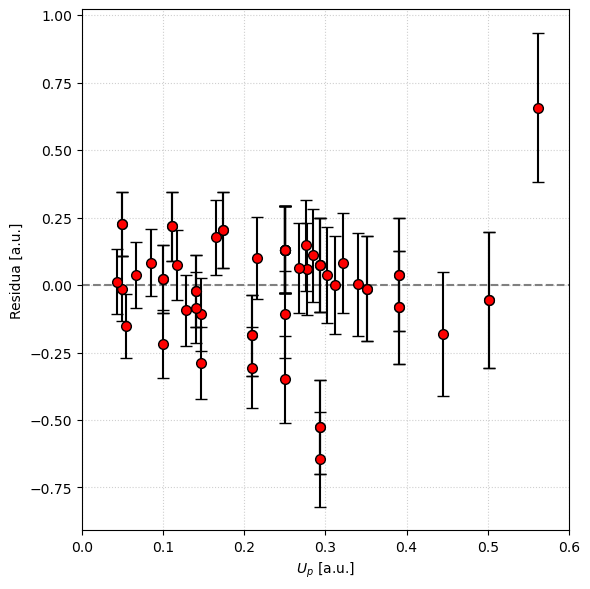

In [224]:
# --- Wykres rezyduów dla modelu regresji metody dipolowej ---

plt.figure(figsize=(6, 6))

# Rysowanie punktów rezyduów wraz z naniesionymi przedziałami niepewności (2-sigma)
plt.errorbar(
    X_d,
    residua_d,
    yerr=yerr_residua_d,
    fmt="o",          # Kształt punktu (okrąg)
    color="red",
    ecolor="black",   # Kolor wąsów błędu
    elinewidth=1.5,   # Grubość linii wąsów
    capsize=4,        # Szerokość poprzecznych daszków na końcach wąsów
    ms=7,             # Wielkość punktu
    mec="k",          # Kolor krawędzi punktu (czarny)
    zorder=5,
)

# Pozioma linia zerowa oznaczająca brak odchylenia (idealne dopasowanie modelu do danych)
ideal_line = np.linspace(0, 0.6, 100)
plt.plot(
    ideal_line,
    np.zeros(len(ideal_line)),
    color="gray",
    linestyle="--",
    zorder=1
)

plt.xlabel(r"$U_p$ [a.u.]")
plt.ylabel(r"Residua [a.u.]")
plt.xlim(0, 0.6)
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

In [239]:
# --- Regresja liniowa OLS dla metody twierdzenia Ehrenfesta ---
# Celem jest dopasowanie parametrów modelu E_cutoff = alpha * U_p + beta dla danych uzyskanych bezpośrednio z siły Ehrenfesta.

# Obliczenie rzeczywistej energii odcięcia Y_Eh (rząd harmonicznej pomnożony przez częstość lasera podstawowego)
df_Eh["Y_Eh"] = df_Eh["N_cutoff_Eh"] * df_Eh["omega_0"]

# Przygotowanie zmiennych X oraz y do pakietu statsmodels.
X_Eh = df_Eh["U_p"]
X_Eh_with_constant = sm.add_constant(X_Eh)
y_Eh = df_Eh["Y_Eh"]

# Dopasowanie modelu regresji liniowej metodą najmniejszych kwadratów (Ordinary Least Squares)
model_Eh = sm.OLS(y_Eh, X_Eh_with_constant).fit()

# Ekstrakcja współczynników, błędów standardowych (1-sigma) oraz współczynnika determinacji R^2
coefficients_Eh = model_Eh.params
std_errors_Eh = model_Eh.bse
r_squared_Eh = model_Eh.rsquared

# Przypisanie wyników dla nachylenia prostej (alpha) oraz wyrazu wolnego (beta)
alpha_Eh = coefficients_Eh['U_p']
dalpha_Eh = std_errors_Eh['U_p']
beta_Eh = coefficients_Eh['const']
dbeta_Eh = std_errors_Eh['const']

# Wyznaczenie współczynnika przy energii jonizacji (C_I_p), przy założeniu stałej wartości I_p dla danej serii danych
C_I_p_Eh = beta_Eh / df_Eh["I_p"].iloc[0]
dC_I_p_Eh = dbeta_Eh / df_Eh["I_p"].iloc[0]

# --- Prezentacja wyników ---
# Wyświetlenie dopasowanych parametrów wraz z przedziałem ufności 2-sigma
print("--- WYNIKI DOPASOWANIA (2-sigma) ---")
print(f"Alpha   : {alpha_Eh:.4f} ± {2 * dalpha_Eh:.4f}")
print(f"Beta    : {beta_Eh:.4f} ± {2 * dbeta_Eh:.4f}")
print(f"C_I_p   : {C_I_p_Eh:.4f} ± {2 * dC_I_p_Eh:.4f}")
print(f"R^2     : {r_squared_Eh:.5f}")

--- WYNIKI DOPASOWANIA (2-sigma) ---
Alpha   : 3.1703 ± 0.1423
Beta    : 0.6272 ± 0.0552
C_I_p   : 1.2543 ± 0.1103
R^2     : 0.96877


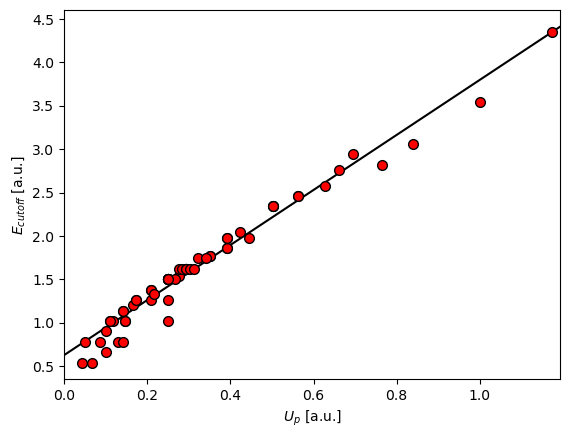

In [226]:
# --- Wykres regresji liniowej energii odcięcia dla metody Ehrenfesta ---
# Wykres przedstawia wyznaczoną energię odcięcia (E_cutoff) w funkcji energii ponderomotorycznej (U_p) dla metody Ehrenfesta.

# Przygotowanie siatki argumentów dla prostej regresyjnej
x_Eh_temp = np.linspace(0, np.max(X_Eh) + 0.02, 1000)

plt.figure(figsize=(8, 5))

# Rysowanie punktów pomiarowych uzyskanych z twierdzenia Ehrenfesta
plt.errorbar(
    X_Eh,
    y_Eh,
    fmt="o",        # Kształt punktu (okrąg)
    color="red",
    ms=7,           # Wielkość punktu
    mec="k",        # Kolor krawędzi punktu (czarny)
    zorder=5,       # Rysowanie punktów nad linią regresji
    label="Dane z symulacji TDSE (Ehrenfest)",
)

# Rysowanie dopasowanej prostej regresyjnej: y = alpha * U_p + beta
plt.plot(
    x_Eh_temp, 
    alpha_Eh * x_Eh_temp + beta_Eh, 
    color='k',
    linestyle='-',
    lw=1.5,
    label=f"Dopasowanie OLS ($\alpha$ = {alpha_Eh:.2f})"
)

# Konfiguracja osi i estetyki wykresu
plt.xlim(0, X_Eh.max() + 0.02)
plt.xlabel(r"$U_p$ [a.u.]")
plt.ylabel(r"$E_{cutoff}$ [a.u.]")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left")
plt.tight_layout()

plt.show()

In [227]:
# --- Analiza rezyduów i propagacja niepewności dla metody Ehrenfesta ---

# Obliczenie wartości teoretycznych (przewidywanych przez model OLS) dla punktów pomiarowych
y_pred_X_Eh = alpha_Eh * X_Eh + beta_Eh

# Obliczenie niepewności standardowej (1-sigma) dla wartości przewidywanych.
dy_1s_Eh = np.sqrt((X_Eh**2) * (dalpha_Eh**2) + (dbeta_Eh**2))

# Przeliczenie na niepewność 2-sigma, odpowiadającą przedziałowi ufności ok. 95%
yerr_residua_Eh = 2 * dy_1s_Eh

# Obliczenie rezyduów (odchyleń wartości uzyskanych z TDSE od prostej regresyjnej)
residua_Eh = y_Eh - y_pred_X_Eh

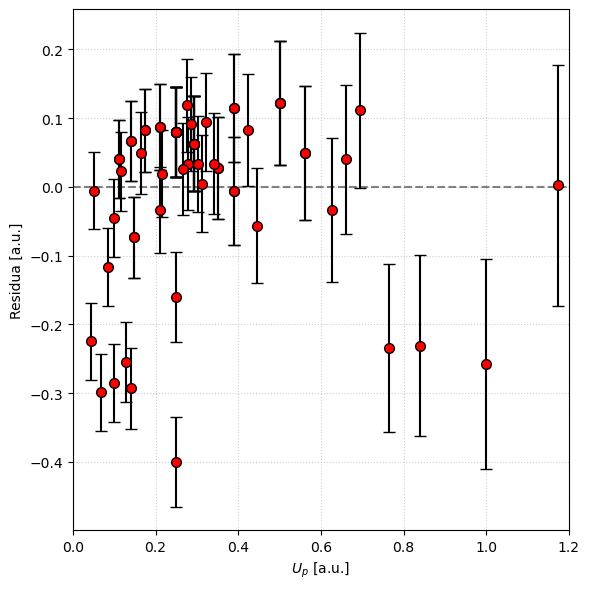

In [228]:
# --- Wykres rezyduów dla modelu regresji metody Ehrenfesta ---

plt.figure(figsize=(6, 6))

# Rysowanie punktów rezyduów wraz z naniesionymi przedziałami niepewności (2-sigma)
plt.errorbar(
    X_Eh,
    residua_Eh,
    yerr=yerr_residua_Eh,
    fmt="o",          # Kształt punktu (okrąg)
    color="red",
    ecolor="black",   # Kolor wąsów błędu
    elinewidth=1.5,   # Grubość linii wąsów
    capsize=4,        # Szerokość poprzecznych daszków na końcach wąsów
    ms=7,             # Wielkość punktu
    mec="k",          # Kolor krawędzi punktu (czarny)
    zorder=5,
)

# Pozioma linia zerowa oznaczająca brak odchylenia (idealne dopasowanie modelu do danych)
ideal_line = np.linspace(0, 1.2, 100)
plt.plot(
    ideal_line,
    np.zeros(len(ideal_line)),
    color="gray",
    linestyle="--",
    zorder=1
)

plt.xlabel(r"$U_p$ [a.u.]")
plt.ylabel(r"Residua [a.u.]")
plt.xlim(0, 1.2)
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()

# Zapis wykresu rezyduów do pliku PDF (dodano brakujący zapis analogicznie do metody dipolowej)
plt.savefig("Residua_Eh.pdf", bbox_inches='tight')
plt.show()

In [77]:
# --- Definicja parametrów lasera dla klasycznego rozwiązania modelu Trójstopniowego  ---

omega_0 = 0.06
U_p = 1

In [78]:
# --- Definicja czasu powrotu elektronu do atomu  ---

l = 1
# Siatka czasu tau reprezentująca czas spędzony przez elektron w kontinuum (od jonizacji do powrotu)
tau = np.linspace(0.00001, l * 2 * np.pi / omega_0, l * 50000)

# Obliczenie momentu jonizacji t_i przy użyciu funkcji np.arctan2 (zwraca kąt w odpowiedniej ćwiartce)
# Równanie wynika bezpośrednio z warunku powrotu elektronu do położenia x(t) = 0.
num = omega_0 * tau - np.sin(omega_0 * tau)
den = np.cos(omega_0 * tau) - 1
arctan_part = np.arctan2(num, den)

C:\Users\Maciej\AppData\Local\Temp\ipykernel_22276\3698887283.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


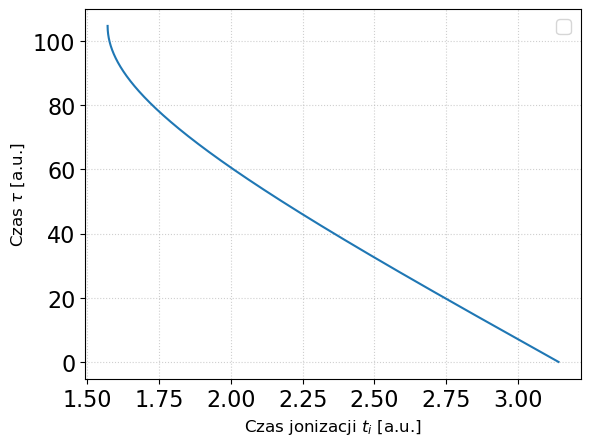

In [79]:
# Wizualizacja relacji między czasem jonizacji a czasem powrotu

plt.plot(arctan_part / omega_0, tau)
plt.xlabel(r"Czas jonizacji $t_i$ [a.u.]", fontsize=12)
plt.ylabel(r"Czas $\tau$ [a.u.]", fontsize=12)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()

In [80]:
# --- Obliczenie energii kinetycznej powracającego elektronu ---
# Równanie na energię kinetyczną T przekazywaną przez elektron w momencie powrotu do jądra.
# Wyrażone przez energię ponderomotoryczną U_p.

# Człony trygonometryczne wynikające z całkowania równania ruchu elektronu w polu elektrycznym
sin_term1 = np.sin(omega_0 * tau / 2) ** 2
sin_term2 = np.sin(omega_0 * tau / 2 + arctan_part) ** 2

# Klasyczna energia kinetyczna elektronu w funkcji czasu spędzonego w kontinuum (tau)
T = 8 * U_p * sin_term1 * sin_term2

(50000,)

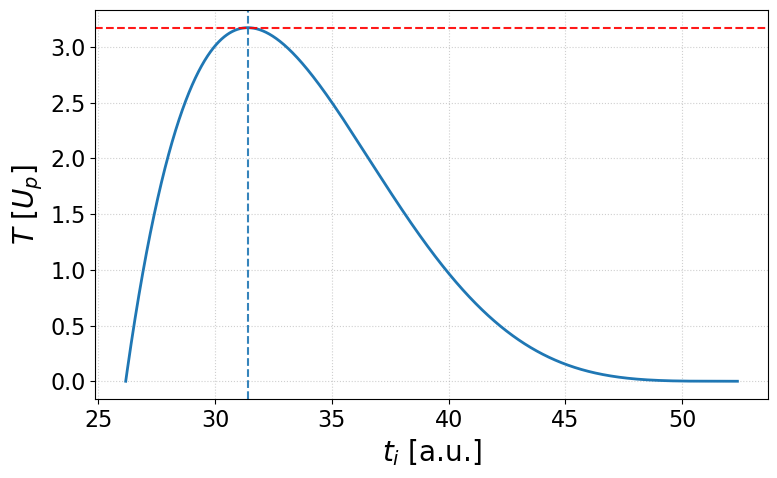

In [81]:
# --- Wykres zależności energii kinetycznej elektronu od momentu jonizacji ---
# Kod wizualizuje klasyczny profil energii powracającego elektronu w funkcji czasu jonizacji (t_i).
# Pozwala wyznaczyć punkt krytyczny, dla którego energia kinetyczna osiąga maksimum (analityczny limit 3.17 U_p).

# Odwinięcie fazy przy użyciu np.unwrap dla zapewnienia ciągłości osi czasu
arctan_unwrapped = np.unwrap(arctan_part)

# Przeliczenie fazy na rzeczywisty czas jonizacji t_i [a.u.]
t_i = (1 / omega_0) * arctan_unwrapped

# Rysowanie wykresu T(t_i)
plt.figure(figsize=(8, 5))
plt.plot(t_i, T, linewidth=2, color="blue", label="Rozkład energii kinetycznej")

# Znalezienie maksimum energii oraz odpowiadającego mu czasu jonizacji
max_T_val = np.max(T)
t_i_max = t_i[np.argmax(T)]

# Linie referencyjne dla energii maksymalnej oraz czasu jonizacji optymalnej trajektorii
plt.axhline(max_T_val, color="red", linestyle="--", alpha=0.9, label=r"$T_{max} \approx 3.17 \, U_p$")
plt.axvline(t_i_max, color="green", linestyle="--", alpha=0.9, label=f"$t_i \\approx {t_i_max:.2f}$ a.u.")

plt.xlabel(r"Czas jonizacji $t_i$ [a.u.]")
plt.ylabel(r"Energia kinetyczna $T$ [$U_p$]")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper right")

plt.tight_layout()
plt.show()

In [82]:
# --- Definicja parametrów atomowych i polowych w jednostkach atomowych (a.u.) ---

I_p = 0.5  # Potencjał jonizacji atomu wodoru

# Wyznaczenie amplitudy natężenia pola elektrycznego fali laserowej F_0
# Wzór wynika z definicji energii ponderomotorycznej: U_p = F_0^2 / (4 * omega_0^2)
F_0 = np.sqrt(4 * U_p * omega_0**2)

# Obliczenie okresu optycznego fali laserowej (czas trwania jednego cyklu)
T_prop = 2 * np.pi / omega_0

0.12


In [83]:
# Definicja pola elektrycznego
F_ti = F_0 * np.sin(omega_0 * t_i)

In [84]:
# Obliczenie energii wypromieniowanego fotonu w rezultacie
# rekobmbinacji elektronu po jego powrocie do jądra
omega_photon = T + I_p

array([0.5       , 0.5       , 0.5       , ..., 0.50000013, 0.50000003,
       0.5       ], shape=(50000,))

In [86]:
# --- Prawdopodobieństwo jonizacji (Model tunelowy Keldysha / ADK) ---
# Obliczenie szybkości jonizacji elektronu w funkcji momentu wprowadzenia do kontinuum (t_i).

# Pierwszy człon: np.abs(F_ti)**(1.5 - np.sqrt(2 / I_p)) to poprawka kulombowska.
# Drugi człon: np.exp(...) to klasyczny czynnik tunelowy Keldysha dla pola quasi-statycznego.
W_ion = np.abs(F_ti)**(1.5 - np.sqrt(2 / I_p)) * np.exp(-2 * (2 * I_p)**1.5 / (3 * np.abs(F_ti)))

# Wyświetlenie tablicy prawdopodobieństw dla poszczególnych kroków czasowych
W_ion

array([0.        , 0.        , 0.        , ..., 0.01115995, 0.01115995,
       0.01115995], shape=(50000,))

In [87]:
# --- Czynnik dyfuzji pakietu falowego w kontinuum ---
# Modeluje spadek prawdopodobieństwa rekombinacji spowodowany przestrzennym 
# rozmyciem gęstości prawdopodobieństwa elektronu w czasie (tau) spędzonym
# w kontinuum przed powrotem do rdzenia.

W_diff = 1.0 / (tau**1.5)

# Wyświetlenie tablicy czynników dyfuzji
W_diff

array([3.16227766e+07, 1.03584833e+04, 3.67536776e+03, ...,
       9.33218053e-04, 9.33190056e-04, 9.33162060e-04], shape=(50000,))

In [88]:
# --- Czynnik jakobianowy (zagęszczenie stanów w dziedzinie energii) ---
# Transformacja prawdopodobieństwa z dziedziny czasu (t_i) do dziedziny energii (T)
# wymaga uwzględnienia jakobianu przekształcenia |dt_i/dT| = 1 / |dT/dt_i|.
# Człon ten odpowiada za geometryczne wzmocnienie sygnału w okolicy cutoffu.

# Sortowanie zmiennych według rosnącego czasu jonizacji t_i dla poprawnego obliczenia gradientu
sort_idx = np.argsort(t_i)
t_i_s = t_i[sort_idx]
T_s = T[sort_idx]
W_ion_s = W_ion[sort_idx]
W_diff_s = W_diff[sort_idx]
omega_photon_s = omega_photon[sort_idx]

# Numeryczne obliczenie pochodnej dT/dt_i przy użyciu różnic centralnych
dT_dti = np.abs(np.gradient(T_s, t_i_s))

# Stabilizacja numeryczna: zabezpieczenie przed dzieleniem przez zero 
# w punkcie odcięcia widma (gdzie pochodna dT/dt_i naturalnie dąży do zera)
dT_dti = np.where(dT_dti < 1e-5, 1e-5, dT_dti)

# Wyznaczenie jakobianu jako odwrotności pochodnej
W_jacobian = 1.0 / dT_dti

# Wyświetlenie tablicy wartości jakobianu
W_jacobian

array([6.63145620e-01, 6.63145615e-01, 6.63145613e-01, ...,
       1.00000000e+05, 1.00000000e+05, 1.00000000e+05], shape=(50000,))

In [90]:
# --- Pełna półklasyczna intensywność pojedynczej trajektorii ---
# Obliczenie całkowitej emisji dla danej energii 
# jako iloczynu trzech niezależnych czynników fizycznych: prawdopodobieństwa jonizacji tunelowej, 
# dyfuzji przestrzennej pakietu falowego w kontinuum oraz geometrycznego jakobianu (zagęszczenia stanów).

trajectory_intensity = W_ion_s * W_diff_s * W_jacobian

# Wyświetlenie tablicy wynikowych intensywności trajektorii
trajectory_intensity

array([6.90602640e-06, 6.90623353e-06, 6.90644071e-06, ...,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00], shape=(50000,))

In [91]:
# --- Inicjalizacja osi energii i widma HHG ---
# Przygotowanie dyskretnych przedziałów (bins) dla energii emitowanych fotonów (E = T + I_p)
# w celu zmapowania ciągłego rozkładu natężeń trajektorii na końcowe widmo HHG.

num_bins = 150

# Definicja osi energii fotonów: od potencjału jonizacji (I_p) 
# do maksymalnej energii klasycznej powrotu powiększonej o I_p z niewielkim marginesem
photon_energy_axis = np.linspace(I_p, 0.05 + np.max(T) * U_p + I_p, num_bins)

# Inicjalizacja tablicy na zsumowane natężenia składowych widma
spectrum_intensity = np.zeros(num_bins)

In [92]:
# --- Konstrukcja widma HHG metodą dyskretyzacji (binning) ---
# Przypisanie wkładów natężenia z poszczególnych trajektorii półklasycznych 
# do odpowiednich przedziałów energii na osi widmowej. Krok ten pozwala 
# na przejście z reprezentacji trajektorii do widma.

for i in range(len(omega_photon_s)):
    # Wyznaczenie indeksu przedziału (binu) najbliższego energii fotonu danej trajektorii
    bin_idx = np.argmin(np.abs(photon_energy_axis - omega_photon_s[i]))
    
    # Akumulacja intensywności trajektorii w danym kanale energetycznym
    spectrum_intensity[bin_idx] += trajectory_intensity[i]

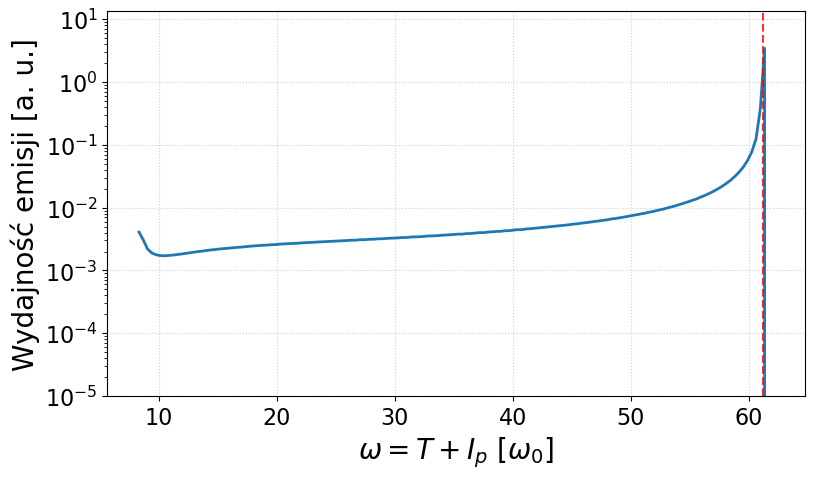

In [96]:
# --- Wykres półklasycznego widma HHG w skali półlogarytmicznej ---
# Wizualizacja końcowego widma HHG.

fig, ax1 = plt.subplots(figsize=(9, 5))

# Rysowanie widma HHG w funkcji rzędu harmonicznej (energia skalowana przez omega_0)
ax1.plot(
    photon_energy_axis / omega_0,
    spectrum_intensity,
    linewidth=2,
    color="tab:blue",
    label="Półklasyczne widmo HHG",
)

# Teoretyczna granica odcięcia (cutoff): E_cutoff = T_max + I_p
# T_max z modelu klasycznego wynosi ~3.17 U_p.
cutoff_energy = np.max(T) + I_p

ax1.axvline(
    cutoff_energy / omega_0,
    color="red",
    linestyle="--",
    alpha=0.8,
    label=r"Granica odcięcia $3.17 U_p + I_p$",
)

# Konfiguracja osi (skala logarytmiczna dla wydajności emisji)
ax1.set_xlabel(r"Rząd harmonicznej $\omega / \omega_0$")
ax1.set_ylabel("Wydajność emisji [a.u.]")
ax1.set_yscale('log')

# Dopasowanie limitów osi Y, zabezpieczające przed błędami skali logarytmicznej
ax1.set_ylim(1e-5, 10 * (1e1 + np.max(spectrum_intensity)))

ax1.grid(True, linestyle=":", alpha=0.6)
ax1.legend(loc="upper right")
plt.tight_layout()

plt.show()